# 02 — Exploratory Data Analysis & Visualization
**CMPE 255 — Student Dropout Prediction Project**

This notebook covers:
- Target class distribution
- Descriptive statistics by class
- Correlation heatmap
- Feature distributions by target
- Boxplots and violin plots
- Cross-tabulations (dropout rate by course, scholarship, etc.)
- PCA 2D projection
- Saving all figures for the presentation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

# Consistent colors
COLORS = {'Dropout': '#E24B4A', 'Enrolled': '#EF9F27', 'Graduate': '#1D9E75'}
ORDER = ['Dropout', 'Enrolled', 'Graduate']

# Load data
df = pd.read_csv('../data/raw/data.csv')
print(f'Loaded {df.shape[0]} rows, {df.shape[1]} columns')
df.head()


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/duylam1407/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/duylam1407/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/duylam1407/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  Fi

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/duylam1407/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/duylam1407/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/duylam1407/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  Fi

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Loaded 4424 rows, 38 columns


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Target_encoded
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,2
2,1,1,5,9070,1,1,122.0,1,37,37,...,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,2
4,2,39,1,8014,0,1,100.0,1,37,38,...,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,2


## 1. Target Class Distribution

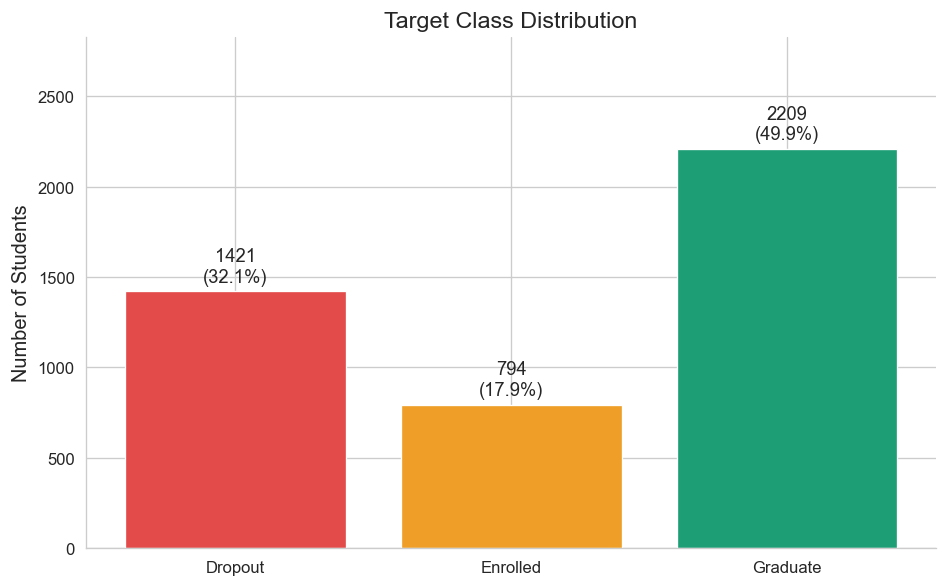

Class distribution:
  Dropout   : 1421 (32.1%)
  Enrolled  : 794 (17.9%)
  Graduate  : 2209 (49.9%)


In [2]:
# 1. Target class distribution — bar chart with counts and percentages
counts = df['Target'].value_counts().reindex(ORDER)
total = len(df)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index, counts.values,
              color=[COLORS[c] for c in counts.index],
              edgecolor='white', linewidth=0.8)
for bar, cnt in zip(bars, counts.values):
    pct = cnt / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f'{cnt}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Number of Students', fontsize=12)
ax.set_title('Target Class Distribution', fontsize=14)
ax.set_ylim(0, counts.max() * 1.28)
sns.despine()
plt.tight_layout()
fig.savefig('../results/figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Class distribution:')
for cls, cnt in counts.items():
    print(f'  {cls:10s}: {cnt} ({cnt/total*100:.1f}%)')

## 2. Correlation Heatmap

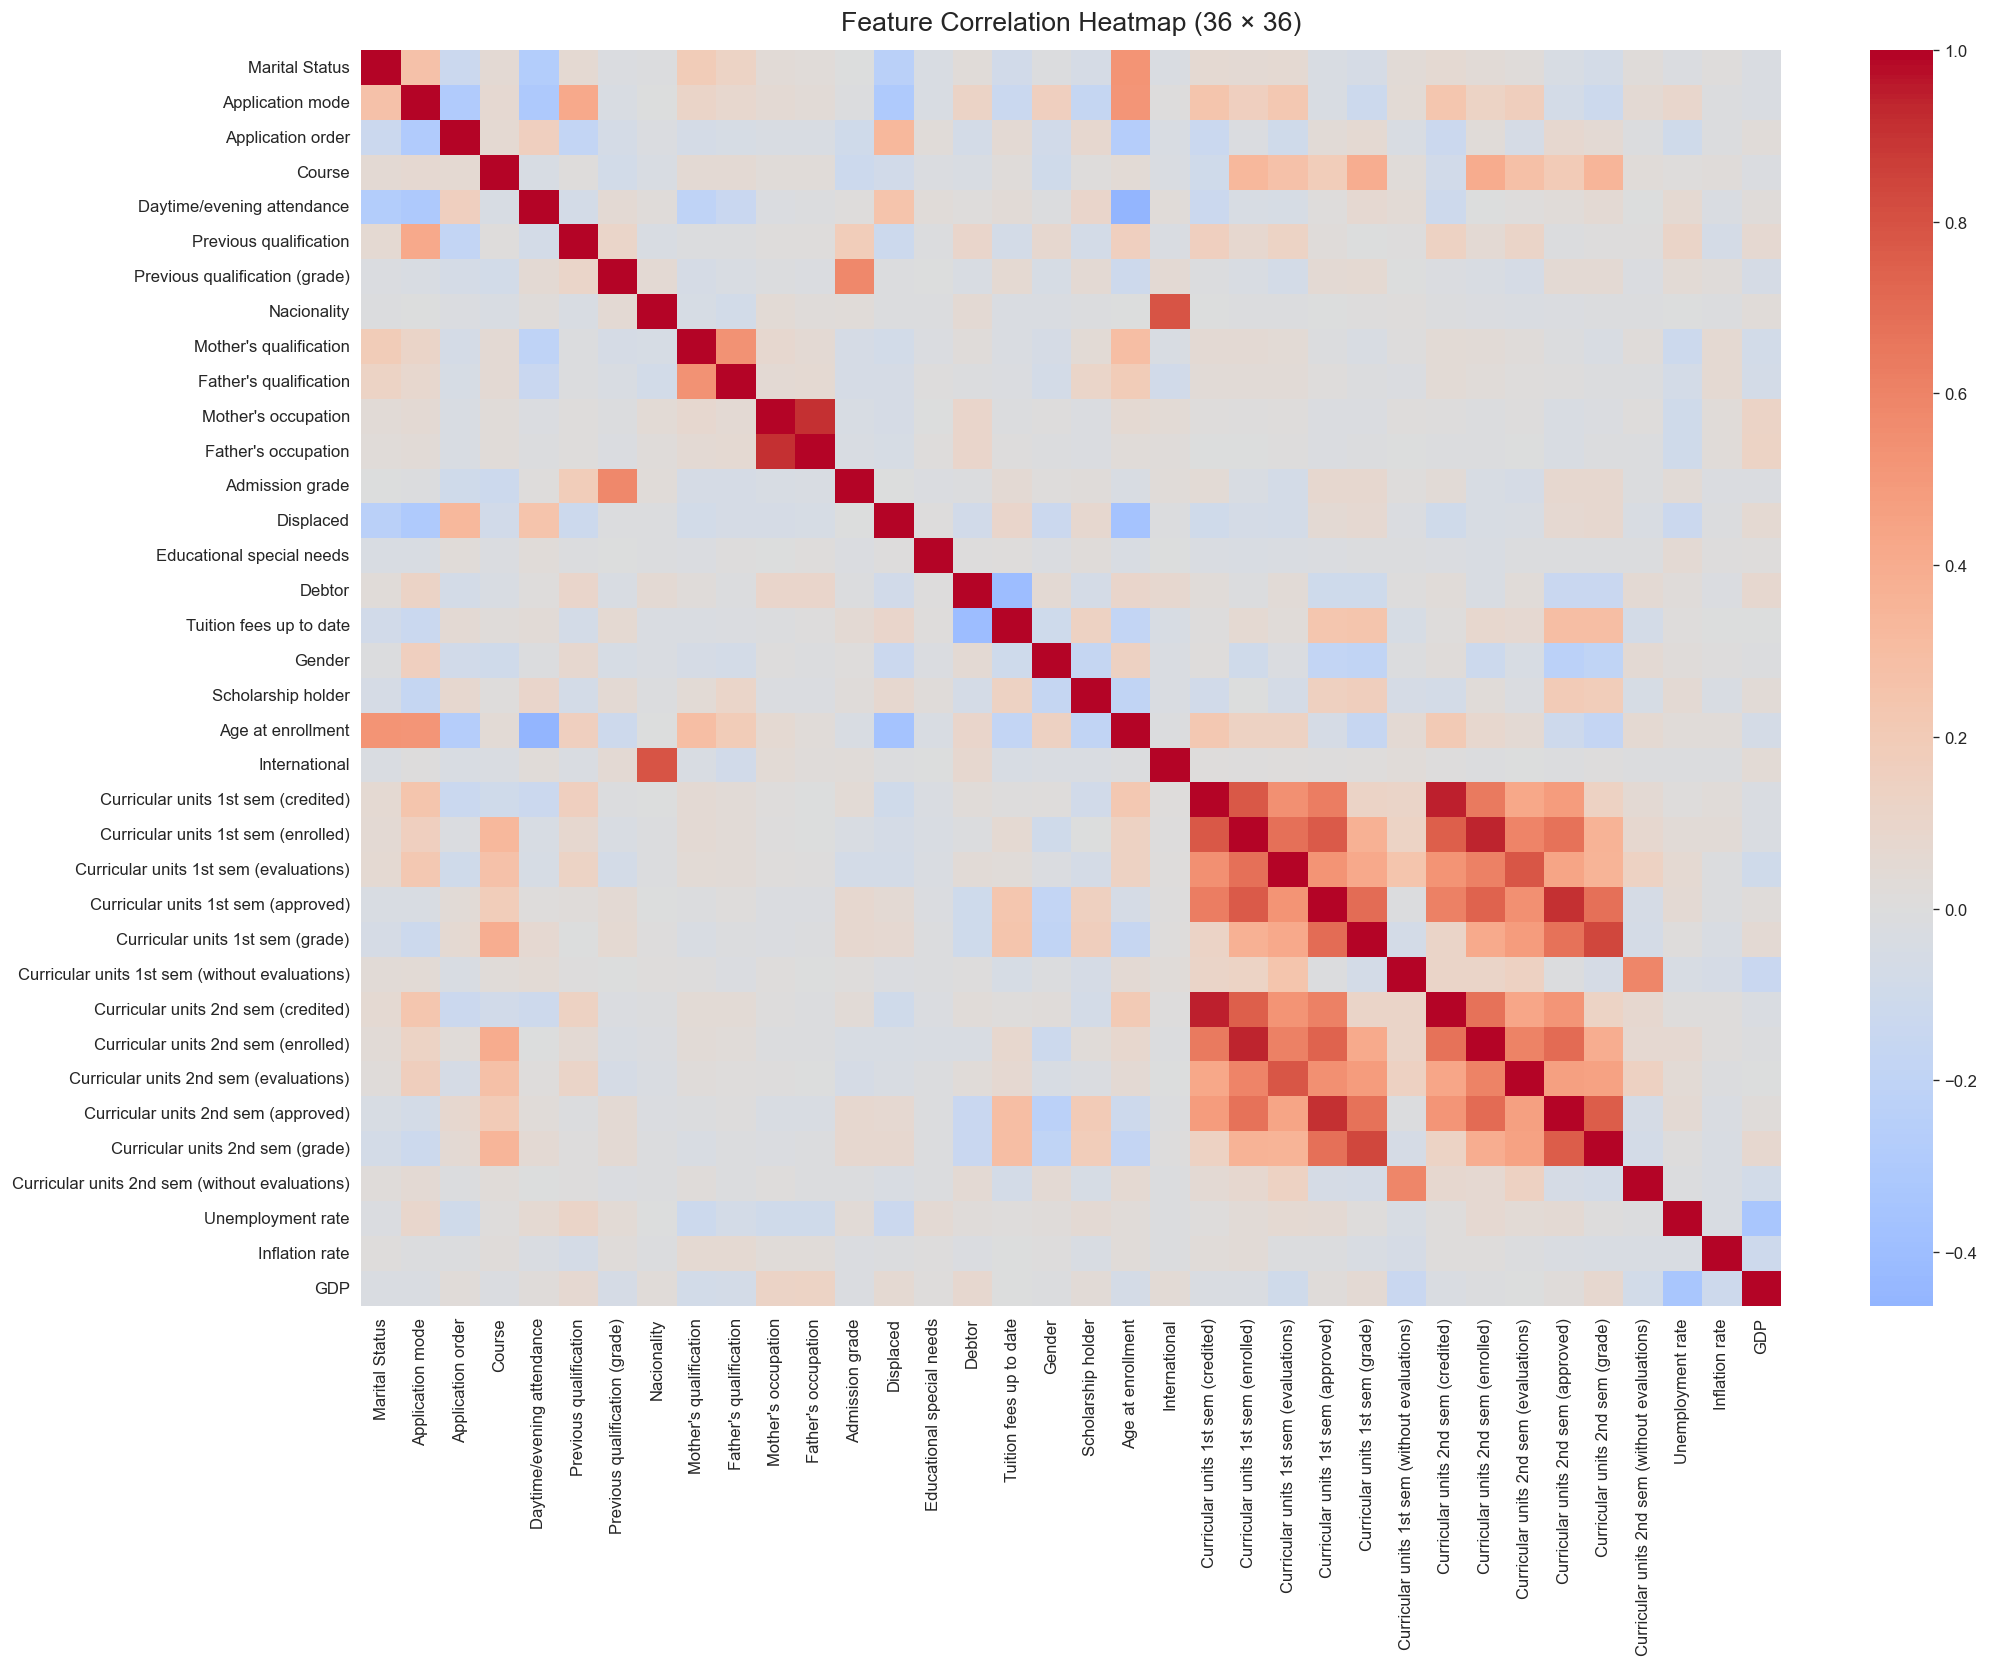

Top 10 features correlated with Target (Pearson |r|):
  ↑ Curricular units 2nd sem (approved): +0.624
  ↑ Curricular units 2nd sem (grade): +0.567
  ↑ Curricular units 1st sem (approved): +0.529
  ↑ Curricular units 1st sem (grade): +0.485
  ↑ Tuition fees up to date: +0.410
  ↑ Scholarship holder: +0.298
  ↓ Age at enrollment: -0.243
  ↓ Debtor: -0.241
  ↓ Gender: -0.229
  ↓ Application mode: -0.222


In [3]:
# 2. Full 36×36 feature correlation heatmap
drop_cols = [c for c in ['Target', 'Target_encoded'] if c in df.columns]
feat_df = df.drop(columns=drop_cols)
corr = feat_df.corr()

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax,
            annot=False, linewidths=0, square=False)
ax.set_title('Feature Correlation Heatmap (36 × 36)', fontsize=16, pad=12)
plt.tight_layout()
fig.savefig('../results/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top features correlated with encoded target
target_enc = df['Target_encoded'] if 'Target_encoded' in df.columns else \
    df['Target'].map({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2})
target_corr = feat_df.corrwith(target_enc)
target_corr_top = target_corr.abs().sort_values(ascending=False).head(10)
print('Top 10 features correlated with Target (Pearson |r|):')
for feat in target_corr_top.index:
    val = target_corr[feat]
    direction = '↑' if val > 0 else '↓'
    print(f'  {direction} {feat}: {val:+.3f}')

## 3. Feature Distributions by Target Class

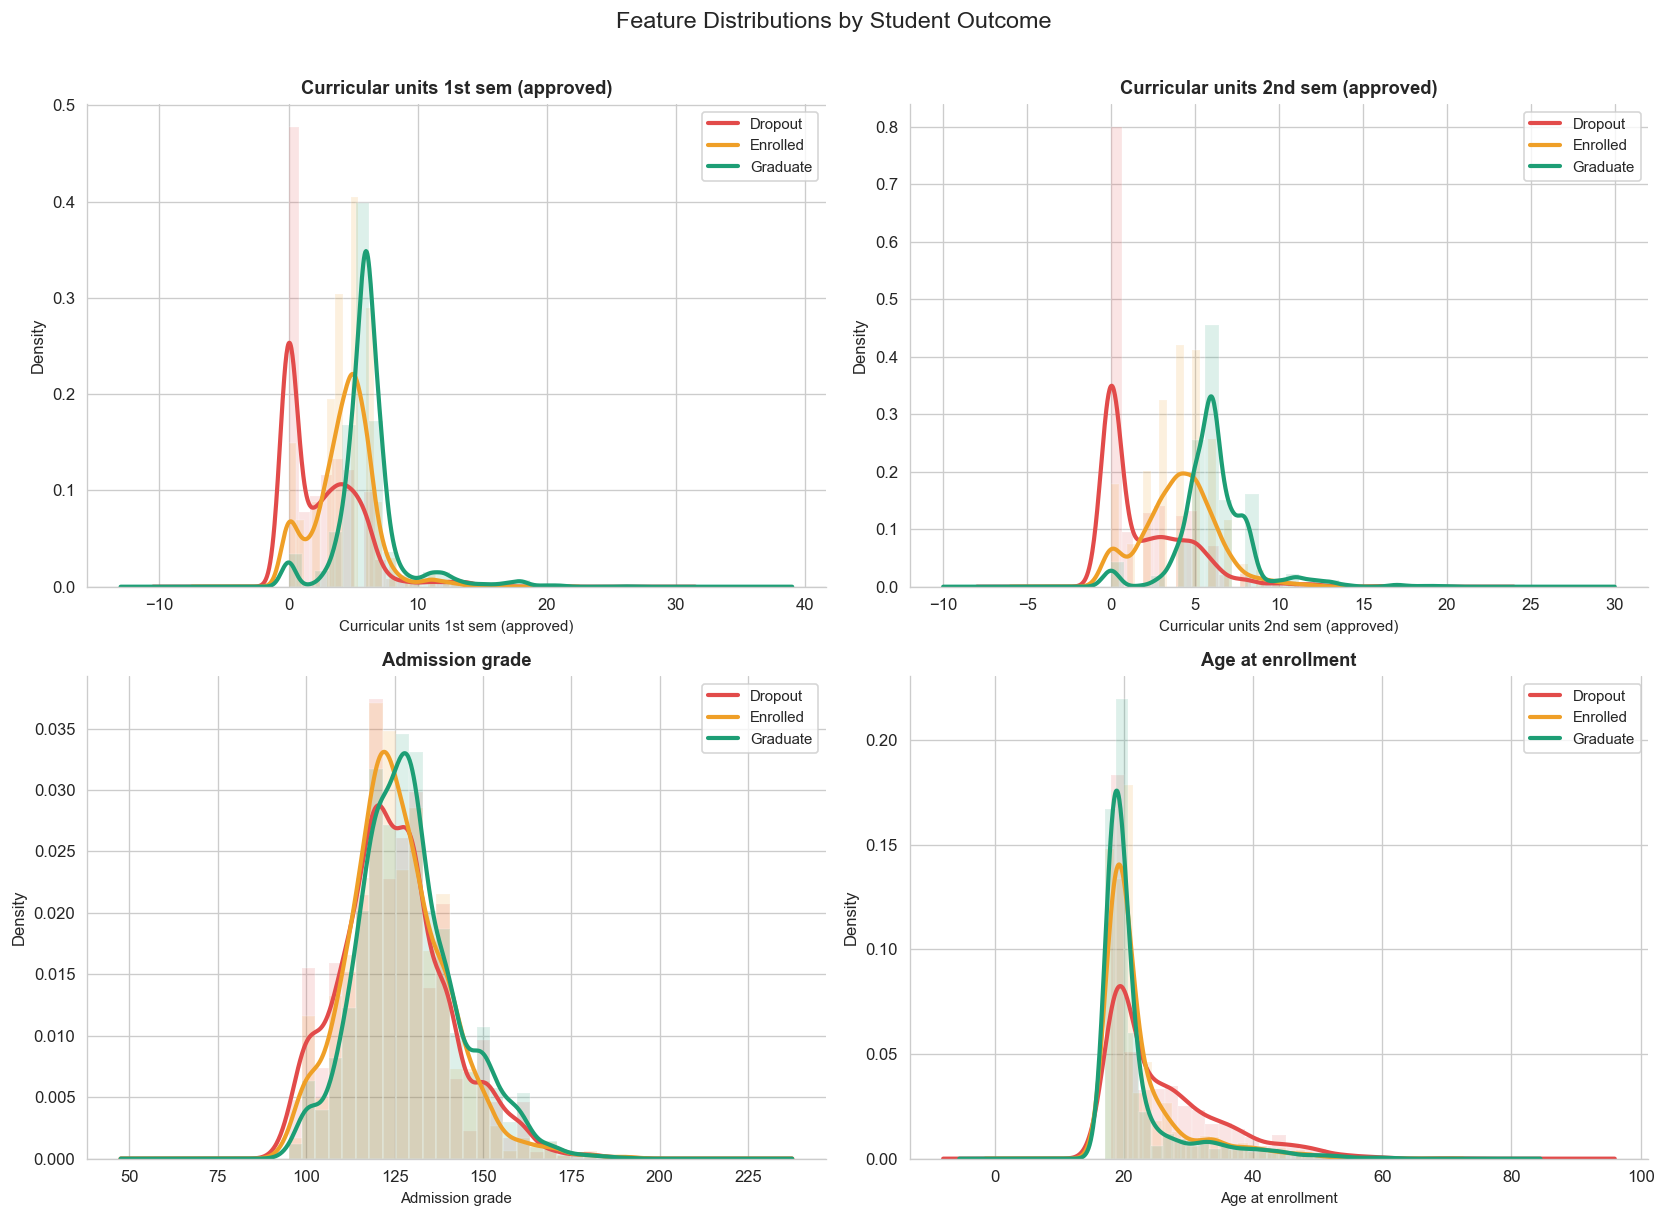

In [4]:
# 3. Feature distributions by target class — 2×2 KDE/histogram subplot grid
key_features = [
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (approved)',
    'Admission grade',
    'Age at enrollment',
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, feat in zip(axes, key_features):
    for cls in ORDER:
        subset = df[df['Target'] == cls][feat].dropna()
        subset.plot.kde(ax=ax, label=cls, color=COLORS[cls], linewidth=2.5)
        ax.hist(subset, bins=25, density=True, alpha=0.15, color=COLORS[cls])
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

fig.suptitle('Feature Distributions by Student Outcome', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig('../results/figures/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Boxplots — Semester Performance by Target

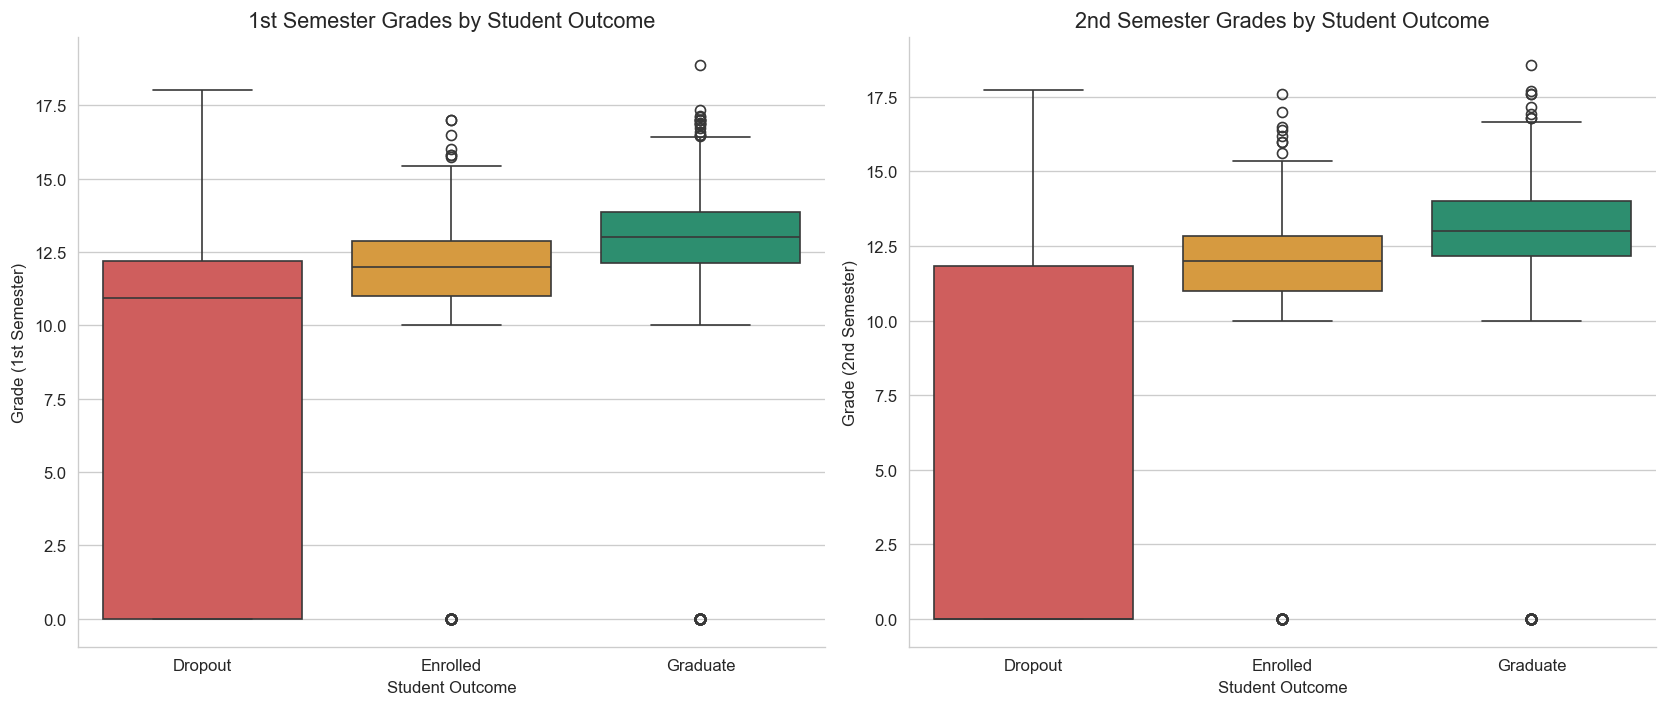

In [5]:
# 4. Boxplots — 1×2 subplot: 1st and 2nd semester grades by target class
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='Target', y='Curricular units 1st sem (grade)',
            order=ORDER, palette=COLORS, ax=axes[0])
axes[0].set_title('1st Semester Grades by Student Outcome', fontsize=13)
axes[0].set_xlabel('Student Outcome')
axes[0].set_ylabel('Grade (1st Semester)')
sns.despine(ax=axes[0])

sns.boxplot(data=df, x='Target', y='Curricular units 2nd sem (grade)',
            order=ORDER, palette=COLORS, ax=axes[1])
axes[1].set_title('2nd Semester Grades by Student Outcome', fontsize=13)
axes[1].set_xlabel('Student Outcome')
axes[1].set_ylabel('Grade (2nd Semester)')
sns.despine(ax=axes[1])

plt.tight_layout()
fig.savefig('../results/figures/boxplots_grades.png', dpi=150, bbox_inches='tight')
plt.show()

### 4a. Five-Number Summary backing the Boxplot

The boxplot above is rendered by seaborn from these exact statistics. Whiskers follow Tukey's 1.5·IQR rule; circles outside are outliers.

In [ ]:
# 4a. Five-number summary by Target class for both semesters
for sem_col in ['Curricular units 1st sem (grade)',
                'Curricular units 2nd sem (grade)']:
    print(f'\n=== {sem_col} — 5-number summary by outcome ===')
    summary = (df.groupby('Target')[sem_col]
                 .describe()[['count', 'min', '25%', '50%', '75%', 'max']]
                 .rename(columns={'25%': 'Q1', '50%': 'median', '75%': 'Q3'})
                 .reindex(ORDER)
                 .round(2))
    summary['IQR'] = (summary['Q3'] - summary['Q1']).round(2)

    # Tukey whiskers and outlier counts
    whisker_lo, whisker_hi, n_out_lo, n_out_hi = [], [], [], []
    for cls in ORDER:
        vals = df.loc[df['Target'] == cls, sem_col].dropna()
        q1, q3 = vals.quantile([0.25, 0.75])
        iqr = q3 - q1
        lo_fence, hi_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        within = vals[(vals >= lo_fence) & (vals <= hi_fence)]
        whisker_lo.append(round(within.min(), 2))
        whisker_hi.append(round(within.max(), 2))
        n_out_lo.append(int((vals < lo_fence).sum()))
        n_out_hi.append(int((vals > hi_fence).sum()))
    summary['whisker_lo'] = whisker_lo
    summary['whisker_hi'] = whisker_hi
    summary['outliers_lo'] = n_out_lo
    summary['outliers_hi'] = n_out_hi

    print(summary.to_string())


## 5. Violin Plot — 2nd Semester Grade Distribution

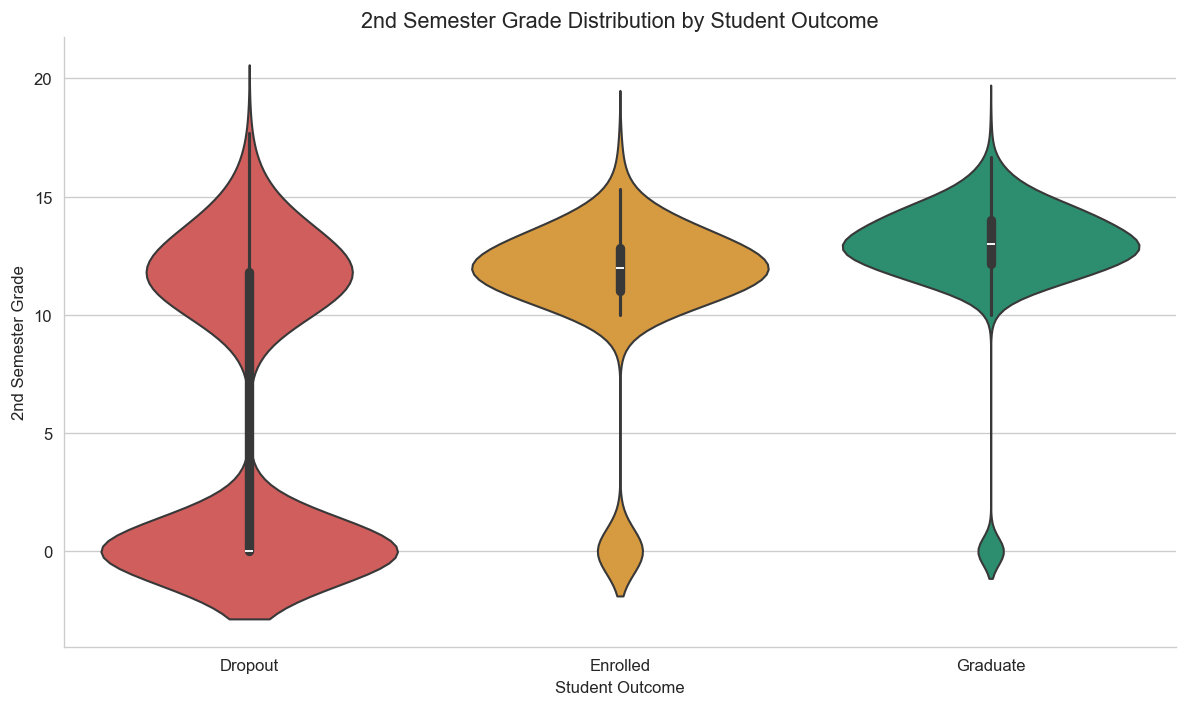

In [6]:
# 5. Violin plot — Curricular units 2nd sem (grade) by target class
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df, x='Target', y='Curricular units 2nd sem (grade)',
               order=ORDER, palette=COLORS, ax=ax, inner='box')
ax.set_title('2nd Semester Grade Distribution by Student Outcome', fontsize=13)
ax.set_xlabel('Student Outcome')
ax.set_ylabel('2nd Semester Grade')
sns.despine(ax=ax)
plt.tight_layout()
fig.savefig('../results/figures/violin_2nd_sem_grade.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Cross-Tabulations

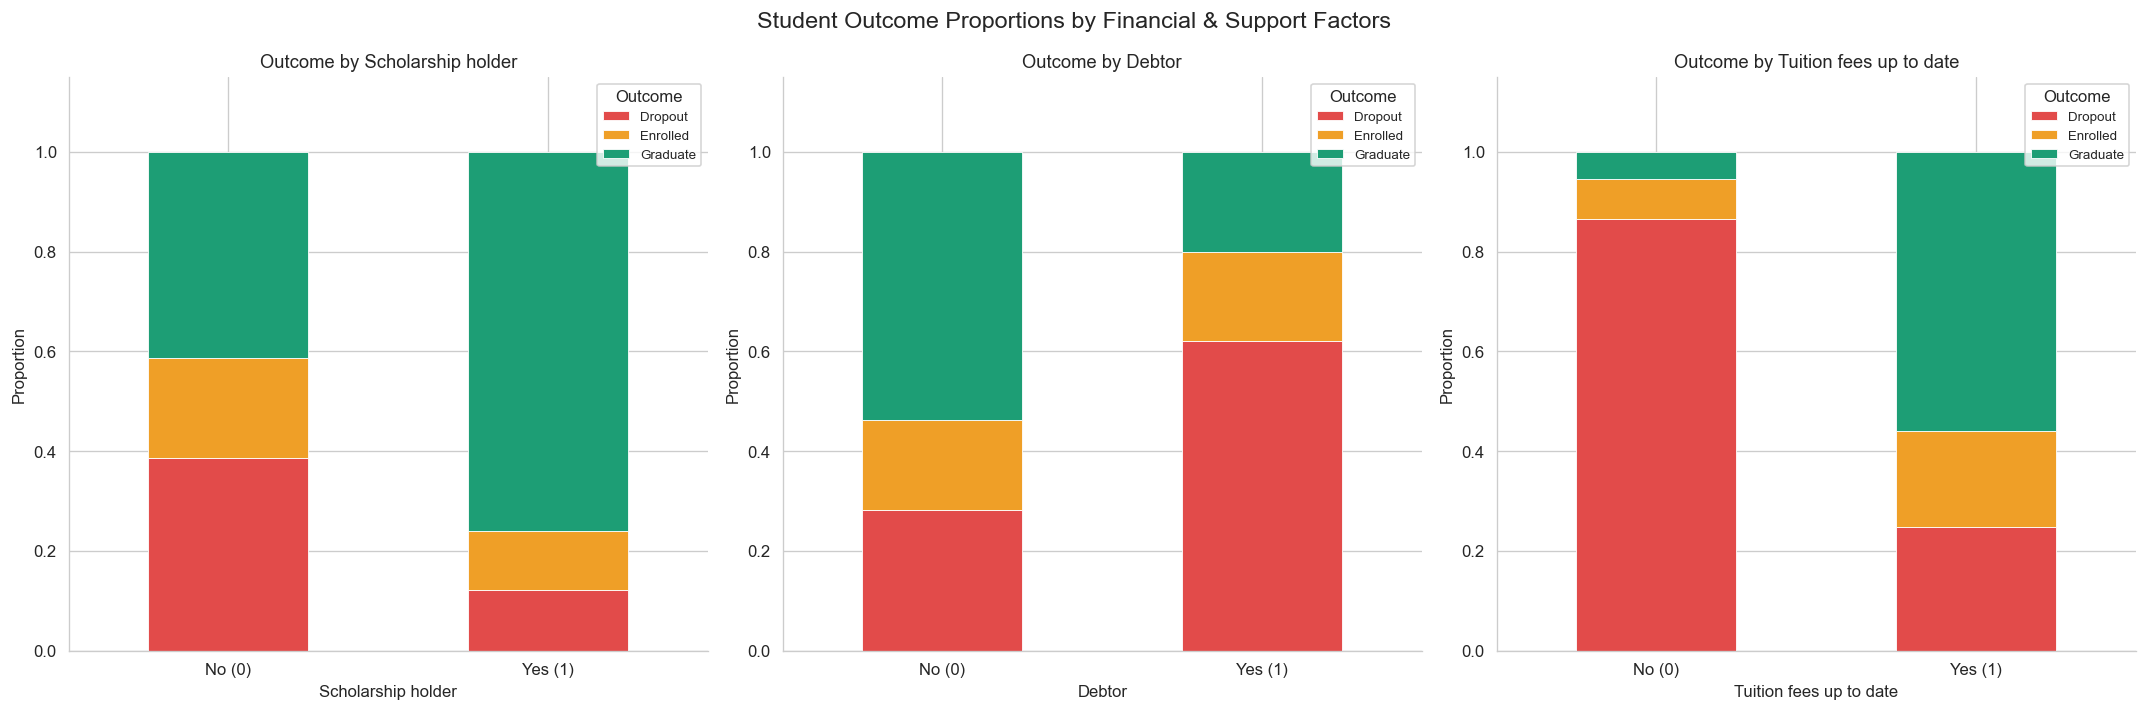

In [7]:
# 6. Stacked bar charts — outcome proportions by Scholarship, Debtor, Tuition (1×3 subplot)
binary_features = ['Scholarship holder', 'Debtor', 'Tuition fees up to date']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, feat in zip(axes, binary_features):
    ct = pd.crosstab(df[feat], df['Target'], normalize='index')[ORDER]
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=[COLORS[c] for c in ORDER], edgecolor='white', linewidth=0.5)
    ax.set_title(f'Outcome by {feat}', fontsize=11)
    ax.set_xlabel(feat)
    ax.set_ylabel('Proportion')
    ax.set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)
    ax.legend(title='Outcome', loc='upper right', fontsize=8)
    ax.set_ylim(0, 1.15)
    sns.despine(ax=ax)

fig.suptitle('Student Outcome Proportions by Financial & Support Factors', fontsize=14)
plt.tight_layout()
fig.savefig('../results/figures/stacked_bar_binary.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. PCA 2D Projection

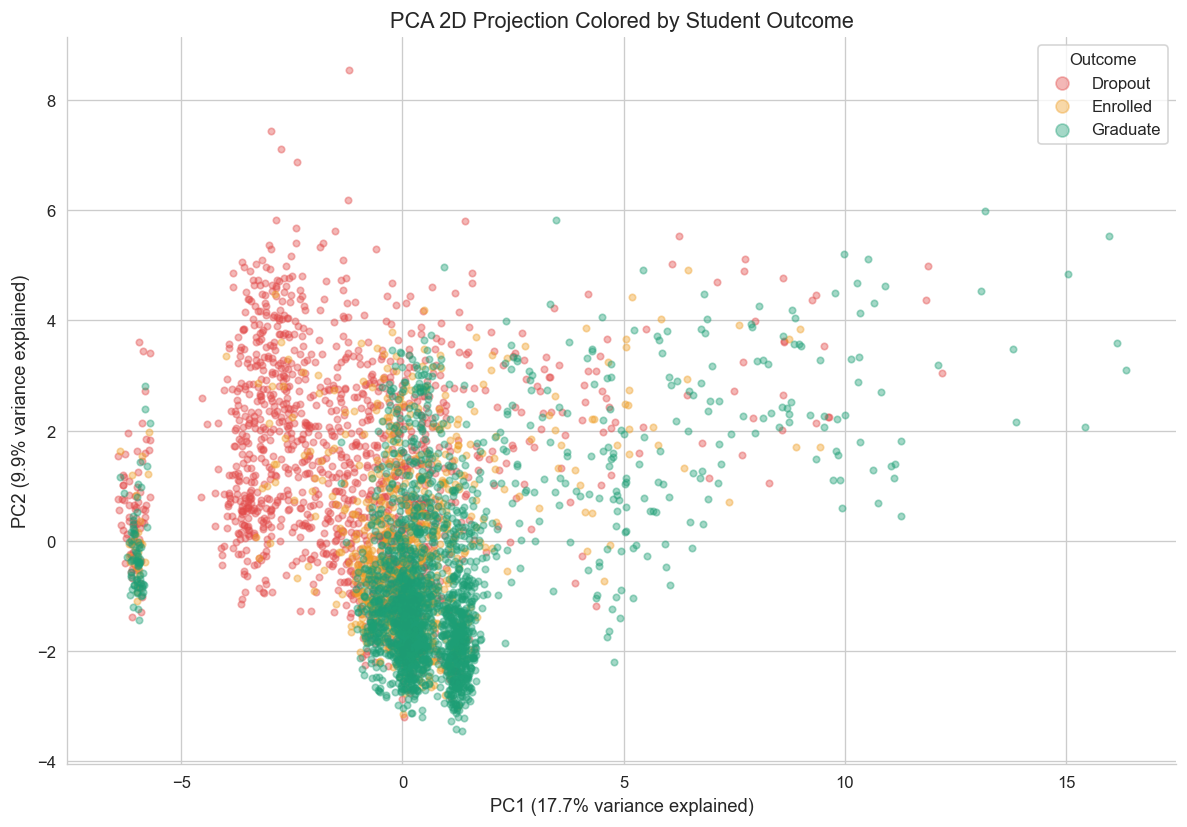

Total variance explained by PC1+PC2: 27.6%


In [8]:
# 7. PCA 2D scatter — project all features to 2D, colored by target class
drop_cols = [c for c in ['Target', 'Target_encoded'] if c in df.columns]
X_pca_input = StandardScaler().fit_transform(df.drop(columns=drop_cols))

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_pca_input)
var_explained = pca.explained_variance_ratio_

pca_df = pd.DataFrame({'PC1': X_pca[:, 0], 'PC2': X_pca[:, 1], 'Target': df['Target']})

fig, ax = plt.subplots(figsize=(10, 7))
for cls in ORDER:
    mask = pca_df['Target'] == cls
    ax.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
               label=cls, color=COLORS[cls], alpha=0.4, s=15)

ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% variance explained)', fontsize=11)
ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% variance explained)', fontsize=11)
ax.set_title('PCA 2D Projection Colored by Student Outcome', fontsize=13)
ax.legend(title='Outcome', markerscale=2)
sns.despine(ax=ax)
plt.tight_layout()
fig.savefig('../results/figures/pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total variance explained by PC1+PC2: {sum(var_explained)*100:.1f}%')

## 8. Top Correlated Features with Target

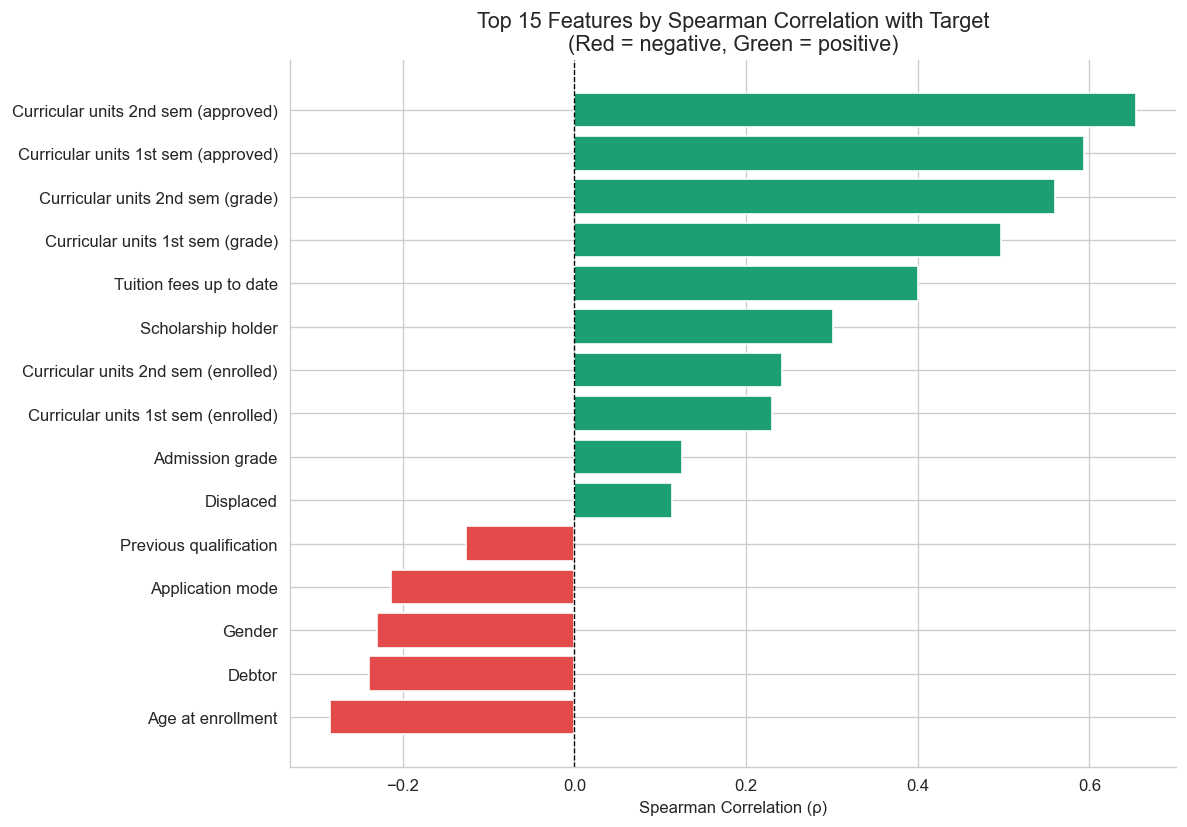

Top 15 features by |Spearman ρ| with Target:
  +0.654  Curricular units 2nd sem (approved)
  +0.594  Curricular units 1st sem (approved)
  +0.560  Curricular units 2nd sem (grade)
  +0.497  Curricular units 1st sem (grade)
  +0.400  Tuition fees up to date
  +0.301  Scholarship holder
  -0.285  Age at enrollment
  +0.241  Curricular units 2nd sem (enrolled)
  -0.239  Debtor
  +0.231  Curricular units 1st sem (enrolled)
  -0.230  Gender
  -0.214  Application mode
  -0.126  Previous qualification
  +0.126  Admission grade
  +0.113  Displaced


In [9]:
# 8. Top 15 features by Spearman correlation with encoded target
from scipy.stats import spearmanr

target_enc = df['Target_encoded'] if 'Target_encoded' in df.columns else \
    df['Target'].map({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2})

drop_cols = [c for c in ['Target', 'Target_encoded'] if c in df.columns]
feat_df = df.drop(columns=drop_cols)

corr_vals = {}
for col in feat_df.columns:
    rho, _ = spearmanr(feat_df[col], target_enc)
    corr_vals[col] = rho

corr_series = pd.Series(corr_vals)
top15 = corr_series.reindex(corr_series.abs().sort_values(ascending=False).index).head(15)
top15_sorted = top15.sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = ['#E24B4A' if v < 0 else '#1D9E75' for v in top15_sorted.values]
ax.barh(top15_sorted.index, top15_sorted.values, color=bar_colors)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Top 15 Features by Spearman Correlation with Target\n(Red = negative, Green = positive)', fontsize=13)
ax.set_xlabel('Spearman Correlation (ρ)')
sns.despine(ax=ax)
plt.tight_layout()
fig.savefig('../results/figures/top_correlated_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 15 features by |Spearman ρ| with Target:')
for feat, val in top15.items():
    print(f'  {val:+.3f}  {feat}')

## 7. Save All Figures
Ensure all figures are saved to `../results/figures/` for the PPT.

In [10]:
print('All figures saved to ../results/figures/')
print('  class_distribution.png')
print('  correlation_heatmap.png')
print('  feature_distributions.png')
print('  boxplots_grades.png')
print('  violin_2nd_sem_grade.png')
print('  stacked_bar_binary.png')
print('  pca_scatter.png')
print('  top_correlated_features.png')

All figures saved to ../results/figures/
  class_distribution.png
  correlation_heatmap.png
  feature_distributions.png
  boxplots_grades.png
  violin_2nd_sem_grade.png
  stacked_bar_binary.png
  pca_scatter.png
  top_correlated_features.png
